In [ ]:
import sys
import math
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from experiment_test import (
    TASKS,
    ROUNDS,
    LOCAL_EPOCHS,
    OUT_ROOT,
    TRAIN_SELECTED_GRAPHS_CSV_PATH,
    TRAIN_SELECTED_EXPERIMENT_LOG_PATH,
    MODEL_CONFIG_KEYS,
)

print("rounds:", ROUNDS)
print("local rounds:", LOCAL_EPOCHS)
print("log dir:", OUT_ROOT)
print("tasks:", TASKS)
print("configs model:", MODEL_CONFIG_KEYS)

rounds: 40
local rounds: 1
log dir: andrea/experiment_test_runs
tasks: ['cycle2', 'cycle3', 'cycle4', 'cycle5']


In [2]:
def normalize_mcw(x):
    if pd.isna(x):
        return 'None'
    return str(x)


def stderr(x):
    x = pd.Series(x).dropna()
    if len(x) <= 1:
        return 0.0
    return x.std(ddof=1) / np.sqrt(len(x))


def resolve_existing_path(path_like):
    p = Path(path_like)
    candidates = [
        p,
        Path.cwd() / p,
        ROOT / p,
        Path('/mnt/data') / p.name,
        Path('/mnt/data') / str(p).replace('andrea/', ''),
        ROOT / str(p).replace('andrea/', ''),
    ]
    for cand in candidates:
        if cand.exists():
            return cand.resolve()
    raise FileNotFoundError(f'Could not resolve path: {path_like}')


def resolve_run_dir(out_dir):
    p = Path(str(out_dir))
    candidates = [
        p,
        Path.cwd() / p,
        ROOT / p,
        ROOT / str(p).replace('andrea/', ''),
        Path('/mnt/data') / p,
        Path('/mnt/data') / str(p).replace('andrea/', ''),
    ]
    for cand in candidates:
        if cand.exists():
            return cand.resolve()
    return None


def cfg_label(mcw_norm, num_layers):
    return f'mcw={mcw_norm} | layers={int(num_layers)}'


def aggregate_curve(curves, x_col, y_col):
    if not curves:
        return pd.DataFrame(columns=[x_col, 'mean', 'std', 'n'])
    df = pd.concat(curves, ignore_index=True)
    out = (
        df.groupby(x_col, as_index=False)[y_col]
          .agg(mean='mean', std='std', n='count')
          .sort_values(x_col)
    )
    out['std'] = out['std'].fillna(0.0)
    return out


def load_local_run(run_dir):
    local_csv = run_dir / 'local.csv'
    if not local_csv.exists():
        raise FileNotFoundError(f'Missing local.csv in {run_dir}')
    return pd.read_csv(local_csv)


def show_selected_overview(selected, tasks):
    if isinstance(selected, pd.DataFrame):
        row = selected.iloc[0]
    else:
        row = selected

    meta_cols = ['graph_id', 'dataset_id', 'type', 'selected_profile']
    for col in meta_cols:
        if col in row.index:
            print(f'{col}: ', row[col])

    records = []
    for task in tasks:
        records.append({
            'task': task,
            'pos_rate_mean': row.get(f'{task}_pos_rate_mean', pd.NA),
            'pos_rate_max_diff_from_mean': row.get(f'{task}_pos_rate_max_diff_from_mean', pd.NA),
            'pos_nodes_mean': row.get(f'{task}_pos_nodes_mean', pd.NA),
            'pos_nodes_max_diff_from_mean': row.get(f'{task}_pos_nodes_max_diff_from_mean', pd.NA),
        })

    overview = pd.DataFrame(records)
    for c in ['pos_rate_mean', 'pos_rate_max_diff_from_mean', 'pos_nodes_mean', 'pos_nodes_max_diff_from_mean']:
        if c in overview.columns:
            overview[c] = pd.to_numeric(overview[c], errors='coerce').round(3)

    display(overview)
    print('\n')
    return overview


def collect_graph_runs(graph_id):
    runs = all_exp[all_exp['graph_id'] == graph_id].copy()
    runs['run_dir'] = runs['out_dir'].apply(resolve_run_dir)
    runs['run_exists'] = runs['run_dir'].apply(lambda x: x is not None)
    return runs


def summarize_best_test(graph_runs):
    scalar_rows = []
    task_rows = []

    for _, run in graph_runs.iterrows():
        run_dir = run['run_dir']
        if run_dir is None:
            continue
        local_df = load_local_run(run_dir)

        best_test = local_df[local_df['phase'] == 'best_test'].copy()
        if not best_test.empty:
            row = best_test.iloc[-1].to_dict()
            row.update({
                'graph_id': run['graph_id'],
                'config': run['config'],
                'mcw_norm': run['mcw_norm'],
                'num_layers': run['num_layers'],
                'seed': run['seed'],
                'run_dir': str(run_dir),
            })
            scalar_rows.append(row)

        best_test_task = local_df[local_df['phase'] == 'best_test_task'].copy()
        if not best_test_task.empty:
            best_test_task = best_test_task.assign(
                graph_id=run['graph_id'],
                config=run['config'],
                mcw_norm=run['mcw_norm'],
                num_layers=run['num_layers'],
                seed=run['seed'],
                run_dir=str(run_dir),
            )
            task_rows.append(best_test_task)

    scalar_df = pd.DataFrame(scalar_rows)
    task_df = pd.concat(task_rows, ignore_index=True) if task_rows else pd.DataFrame()
    return scalar_df, task_df

def always_one_metrics(pos_rate: float) -> dict:
    p = float(pos_rate)
    f1 = 0.0 if p <= 0.0 else (2.0 * p) / (1.0 + p)
    return {
        "threshold": 0.0,
        "f1": f1,
        "auprc": p,
    }

def build_always_one_baseline(graph_row, split_name, task_order):
    rows = []
    for task in task_order:
        # Prefer split-specific positive rate if you have it.
        # Otherwise fall back to the existing overall/task mean.
        split_col = f'{split_name}_{task}_pos_rate_mean'
        generic_col = f'{task}_pos_rate_mean'

        pos_rate = graph_row.get(split_col, graph_row.get(generic_col, np.nan))
        if pd.isna(pos_rate):
            continue

        m = always_one_metrics(pos_rate)
        rows.append({
            'task': task,
            'threshold': m['threshold'],
            'f1': m['f1'],
            'auprc': m['auprc'],
        })

    return pd.DataFrame(rows)

In [3]:
experiment_path = resolve_existing_path(TRAIN_SELECTED_EXPERIMENT_LOG_PATH)
selected_graphs_path = resolve_existing_path(TRAIN_SELECTED_GRAPHS_CSV_PATH)

all_exp = pd.read_csv(experiment_path)
all_exp['mcw_norm'] = all_exp['mcw'].apply(normalize_mcw)
all_exp['config'] = all_exp.apply(lambda r: cfg_label(r['mcw_norm'], r['num_layers']), axis=1)

train_graphs = pd.read_csv(selected_graphs_path)

print('experiment_path:', experiment_path)
print('selected_graphs_path:', selected_graphs_path)
print('num experiment rows:', len(all_exp))
print('num selected graphs:', len(train_graphs))


experiment_path: /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/experiment_test.csv
selected_graphs_path: /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/training_selected_graphs.csv
num experiment rows: 108
num selected graphs: 3


haha


In [8]:
CONFIGS = [
    cfg_label('auto', 3),
    cfg_label('auto', 6),
    cfg_label('None', 3),
    cfg_label('None', 6),
]



def summarize_best_split(graph_runs, split_name):
    scalar_rows = []
    task_rows = []
    scalar_phase = f'best_{split_name}'
    task_phase = f'best_{split_name}_task'

    for _, run in graph_runs.iterrows():
        run_dir = run['run_dir']
        if run_dir is None:
            continue
        local_df = load_local_run(run_dir)

        scalar_part = local_df[local_df['phase'] == scalar_phase].copy()
        if not scalar_part.empty:
            row = scalar_part.iloc[-1].to_dict()
            row.update({
                'graph_id': run['graph_id'],
                'config': run['config'],
                'mcw_norm': run['mcw_norm'],
                'num_layers': run['num_layers'],
                'seed': run['seed'],
                'run_dir': str(run_dir),
                'split': split_name,
            })
            scalar_rows.append(row)

        task_part = local_df[local_df['phase'] == task_phase].copy()
        if not task_part.empty:
            task_part = task_part.assign(
                graph_id=run['graph_id'],
                config=run['config'],
                mcw_norm=run['mcw_norm'],
                num_layers=run['num_layers'],
                seed=run['seed'],
                run_dir=str(run_dir),
                split=split_name,
            )
            task_rows.append(task_part)

    scalar_df = pd.DataFrame(scalar_rows)
    task_df = pd.concat(task_rows, ignore_index=True) if task_rows else pd.DataFrame()
    return scalar_df, task_df



def make_loss_figure_for_graph(graph_row, graph_runs, save_root):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), squeeze=False)
    axes = axes.flatten()

    for ax, config in zip(axes, CONFIGS):
        cfg_runs = graph_runs[graph_runs['config'] == config].copy()
        train_curves = []
        val_curves = []

        for _, run in cfg_runs.iterrows():
            run_dir = run['run_dir']
            if run_dir is None:
                continue
            local_df = load_local_run(run_dir)
            val_df = local_df[local_df['phase'] == 'val'].copy()
            if val_df.empty:
                continue
            val_df = val_df.sort_values('local_epoch')
            train_curves.append(val_df[['local_epoch', 'train_loss']].assign(seed=run['seed']))
            val_curves.append(val_df[['local_epoch', 'val_loss']].assign(seed=run['seed']))

        train_agg = aggregate_curve(train_curves, 'local_epoch', 'train_loss')
        val_agg = aggregate_curve(val_curves, 'local_epoch', 'val_loss')

        if not train_agg.empty:
            x = train_agg['local_epoch'].to_numpy(dtype=float)
            mean = train_agg['mean'].to_numpy(dtype=float)
            std = train_agg['std'].to_numpy(dtype=float)
            ax.plot(x, mean, marker='o', label='train_loss')
            ax.fill_between(x, mean - std, mean + std, alpha=0.2)
        if not val_agg.empty:
            x = val_agg['local_epoch'].to_numpy(dtype=float)
            mean = val_agg['mean'].to_numpy(dtype=float)
            std = val_agg['std'].to_numpy(dtype=float)
            ax.plot(x, mean, marker='s', label='val_loss')
            ax.fill_between(x, mean - std, mean + std, alpha=0.2)

        n_seeds = int(cfg_runs['seed'].nunique()) if len(cfg_runs) else 0
        ax.set_title(f'{config} | n_seeds={n_seeds}')
        ax.set_xlabel('local_epoch')
        ax.set_ylabel('loss')
        ax.grid(alpha=0.3)
        ax.legend()

    fig.suptitle(
        f"graph_id={graph_row['graph_id']} | dataset={graph_row['dataset_id']} | "
        f"profile={graph_row.get('selected_profile', 'NA')} | generator={graph_row.get('type', 'NA')}",
        y=1.02,
    )
    fig.tight_layout()

    save_root.mkdir(parents=True, exist_ok=True)
    save_path = save_root / f"graph_{int(graph_row['graph_id'])}_losses_2x2.png"
    fig.savefig(save_path, dpi=180, bbox_inches='tight')
    plt.show()
    return save_path



def aggregate_task_metric(task_df, metric_col):
    if task_df.empty:
        return pd.DataFrame(columns=['config', 'task', 'mean', 'std', 'n'])
    out = (
        task_df.groupby(['config', 'task'], as_index=False)[metric_col]
               .agg(mean='mean', std='std', n='count')
    )
    out['std'] = out['std'].fillna(0.0)
    return out



def make_task_metric_figure_for_graph(graph_row, task_df, save_root, split_name):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), squeeze=False)
    axes = axes.flatten()
    metric_specs = [
        ('threshold', f'{split_name.upper()} threshold'),
        ('f1', f'{split_name.upper()} F1'),
        ('auprc', f'{split_name.upper()} AUPRC'),
    ]
    task_order = list(TASKS)
    x = np.arange(len(task_order), dtype=float)
    width = 0.2

    # NEW: build always-1 dummy baseline once per graph/split
    dummy_df = build_always_one_baseline(graph_row, split_name, task_order)

    for ax, (metric_col, title) in zip(axes, metric_specs):
        agg = aggregate_task_metric(task_df, metric_col)
        if agg.empty:
            ax.set_title(f'{title} (no data)')
            ax.axis('off')
            continue

        # existing bars for the 4 configs
        for i, config in enumerate(CONFIGS):
            sub = agg[agg['config'] == config].copy()
            sub['task'] = pd.Categorical(sub['task'], categories=task_order, ordered=True)
            sub = sub.sort_values('task')

            means = [np.nan] * len(task_order)
            stds = [0.0] * len(task_order)
            for j, task in enumerate(task_order):
                row = sub[sub['task'] == task]
                if not row.empty:
                    means[j] = float(row['mean'].iloc[0])
                    stds[j] = float(row['std'].iloc[0])

            xpos = x + (i - 1.5) * width
            ax.bar(xpos, means, width=width, label=config, yerr=stds, capsize=3, alpha=0.85)

        # NEW: overlay always-1 dummy baseline without changing the plot structure
        if not dummy_df.empty and metric_col in dummy_df.columns:
            dummy_sub = dummy_df.set_index('task').reindex(task_order)
            dummy_vals = dummy_sub[metric_col].to_numpy(dtype=float)

            ax.plot(
                x,
                dummy_vals,
                linestyle='--',
                marker='D',
                linewidth=2,
                label='always_1'
            )

        ax.set_title(title)
        ax.set_xticks(x)
        ax.set_xticklabels(task_order, rotation=30, ha='right')
        ax.grid(axis='y', alpha=0.3)

        if metric_col in {'f1', 'auprc'}:
            ax.set_ylim(0, 1.05)
        elif metric_col == 'threshold':
            ax.set_ylim(bottom=0)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.10))

    fig.suptitle(
        f"graph_id={graph_row['graph_id']} | dataset={graph_row['dataset_id']} | "
        f"profile={graph_row.get('selected_profile', 'NA')} | generator={graph_row.get('type', 'NA')} | split={split_name}",
        y=1.18,
    )
    fig.tight_layout()

    save_root.mkdir(parents=True, exist_ok=True)
    save_path = save_root / f"graph_{int(graph_row['graph_id'])}_{split_name}_task_metrics.png"
    fig.savefig(save_path, dpi=180, bbox_inches='tight')
    plt.show()
    return save_path



def aggregate_scalar_metric(scalar_df, metric_col):
    if scalar_df.empty:
        return pd.DataFrame(columns=['config', 'mean', 'std', 'n'])
    out = (
        scalar_df.groupby('config', as_index=False)[metric_col]
                 .agg(mean='mean', std='std', n='count')
    )
    out['std'] = out['std'].fillna(0.0)
    return out



def make_scalar_metric_figure_for_graph(graph_row, scalar_df, save_root, split_name):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), squeeze=False)
    axes = axes.flatten()
    metric_specs = [
        ('best_epoch', f'{split_name.upper()} best_epoch'),
        ('eval_loss', f'{split_name.upper()} eval_loss'),
        ('micro_f1', f'{split_name.upper()} micro_f1'),
        ('macro_f1', f'{split_name.upper()} macro_f1'),
    ]
    x = np.arange(len(CONFIGS), dtype=float)

    for ax, (metric_col, title) in zip(axes, metric_specs):
        agg = aggregate_scalar_metric(scalar_df, metric_col)
        if agg.empty:
            ax.set_title(f'{title} (no data)')
            ax.axis('off')
            continue

        means = []
        stds = []
        ns = []
        for config in CONFIGS:
            row = agg[agg['config'] == config]
            if row.empty:
                means.append(np.nan)
                stds.append(0.0)
                ns.append(0)
            else:
                means.append(float(row['mean'].iloc[0]))
                stds.append(float(row['std'].iloc[0]))
                ns.append(int(row['n'].iloc[0]))

        ax.bar(x, means, yerr=stds, capsize=4, alpha=0.85)
        ax.set_title(title)
        ax.set_xticks(x)
        ax.set_xticklabels([c.replace(' | ', '\n') for c in CONFIGS], rotation=0)
        ax.grid(axis='y', alpha=0.3)
        if metric_col in {'micro_f1', 'macro_f1'}:
            ax.set_ylim(0, 1.05)
        elif metric_col == 'eval_loss':
            ax.set_ylim(bottom=0)

        for xi, m, s, n in zip(x, means, stds, ns):
            if pd.notna(m):
                ax.text(xi, m + (0.02 if metric_col in {'micro_f1', 'macro_f1'} else 0), f'n={n}', ha='center', va='bottom', fontsize=9)

    fig.suptitle(
        f"graph_id={graph_row['graph_id']} | dataset={graph_row['dataset_id']} | "
        f"profile={graph_row.get('selected_profile', 'NA')} | generator={graph_row.get('type', 'NA')} | split={split_name}",
        y=1.02,
    )
    fig.tight_layout()

    save_root.mkdir(parents=True, exist_ok=True)
    save_path = save_root / f"graph_{int(graph_row['graph_id'])}_{split_name}_scalar_metrics.png"
    fig.savefig(save_path, dpi=180, bbox_inches='tight')
    plt.show()
    return save_path



graph_id:  751
dataset_id:  data_2500_6_5.5_chordal
type:  chordal
selected_profile:  increasing


,task,pos_rate_mean,pos_rate_max_diff_from_mean,pos_nodes_mean,pos_nodes_max_diff_from_mean
0,cycle2,0.331,0.020,826.333,50.333
1,cycle3,0.478,0.023,1195.000,58.000
2,cycle4,0.613,0.019,1533.333,48.667
3,cycle5,0.704,0.012,1759.333,30.333


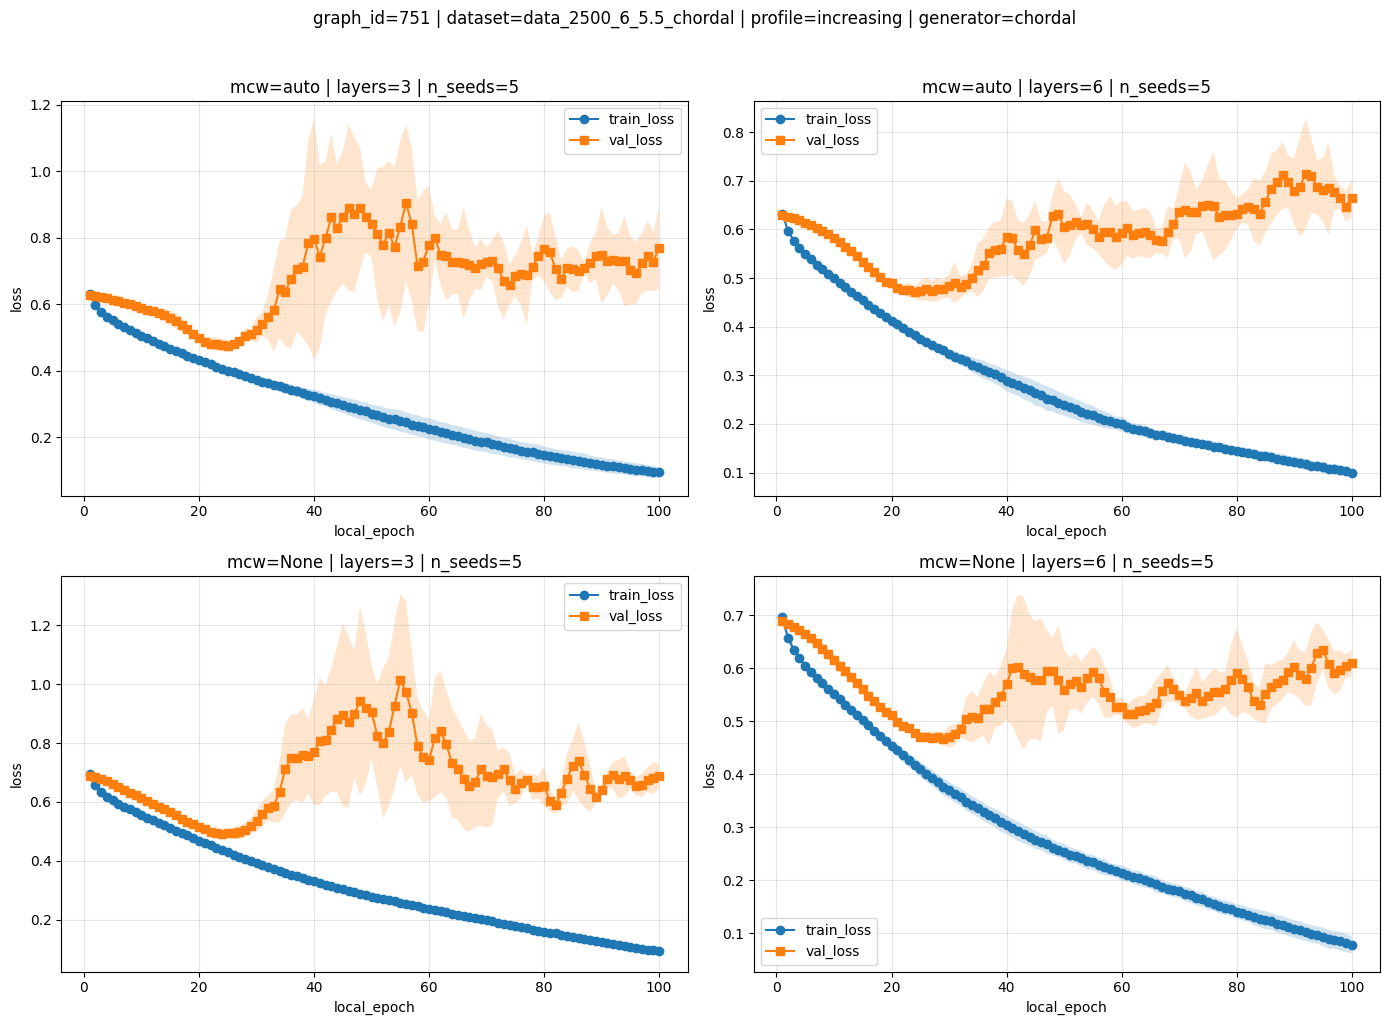

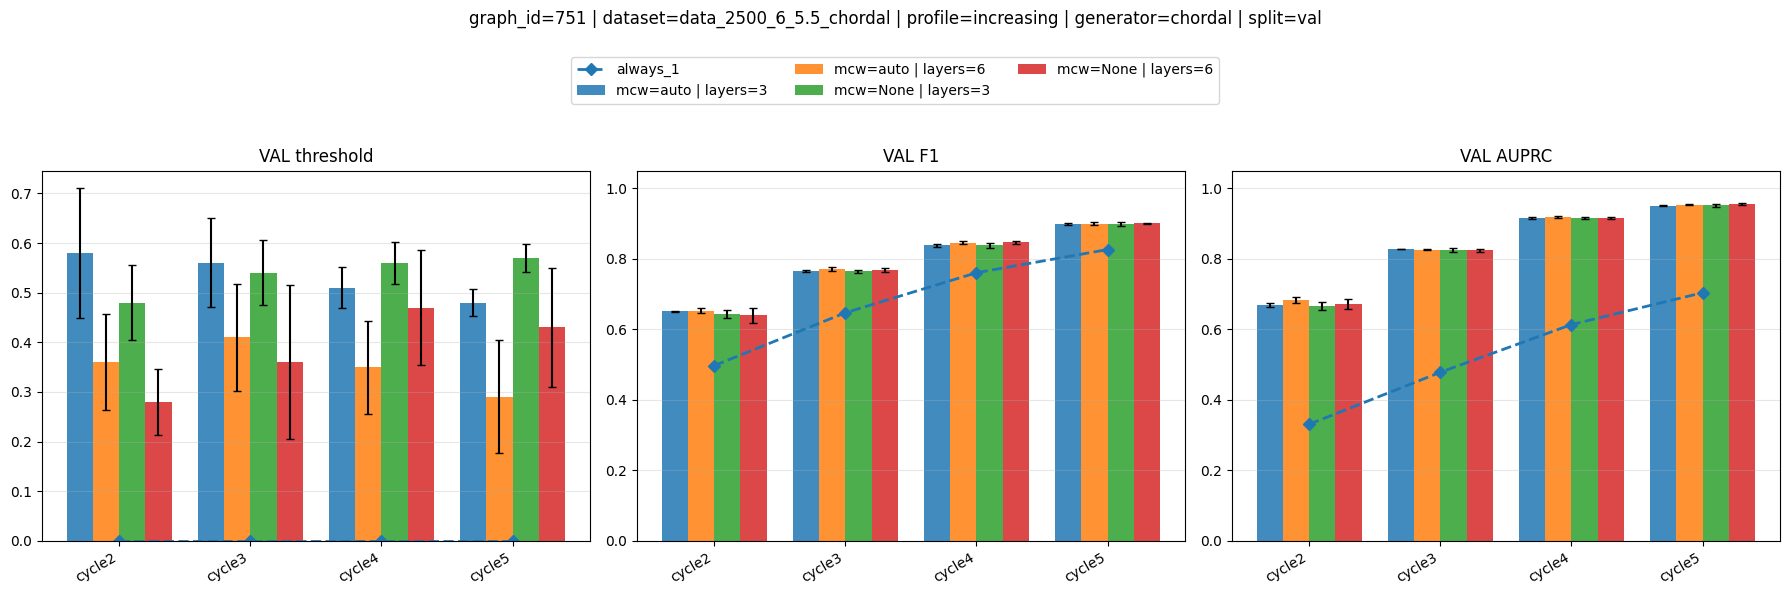

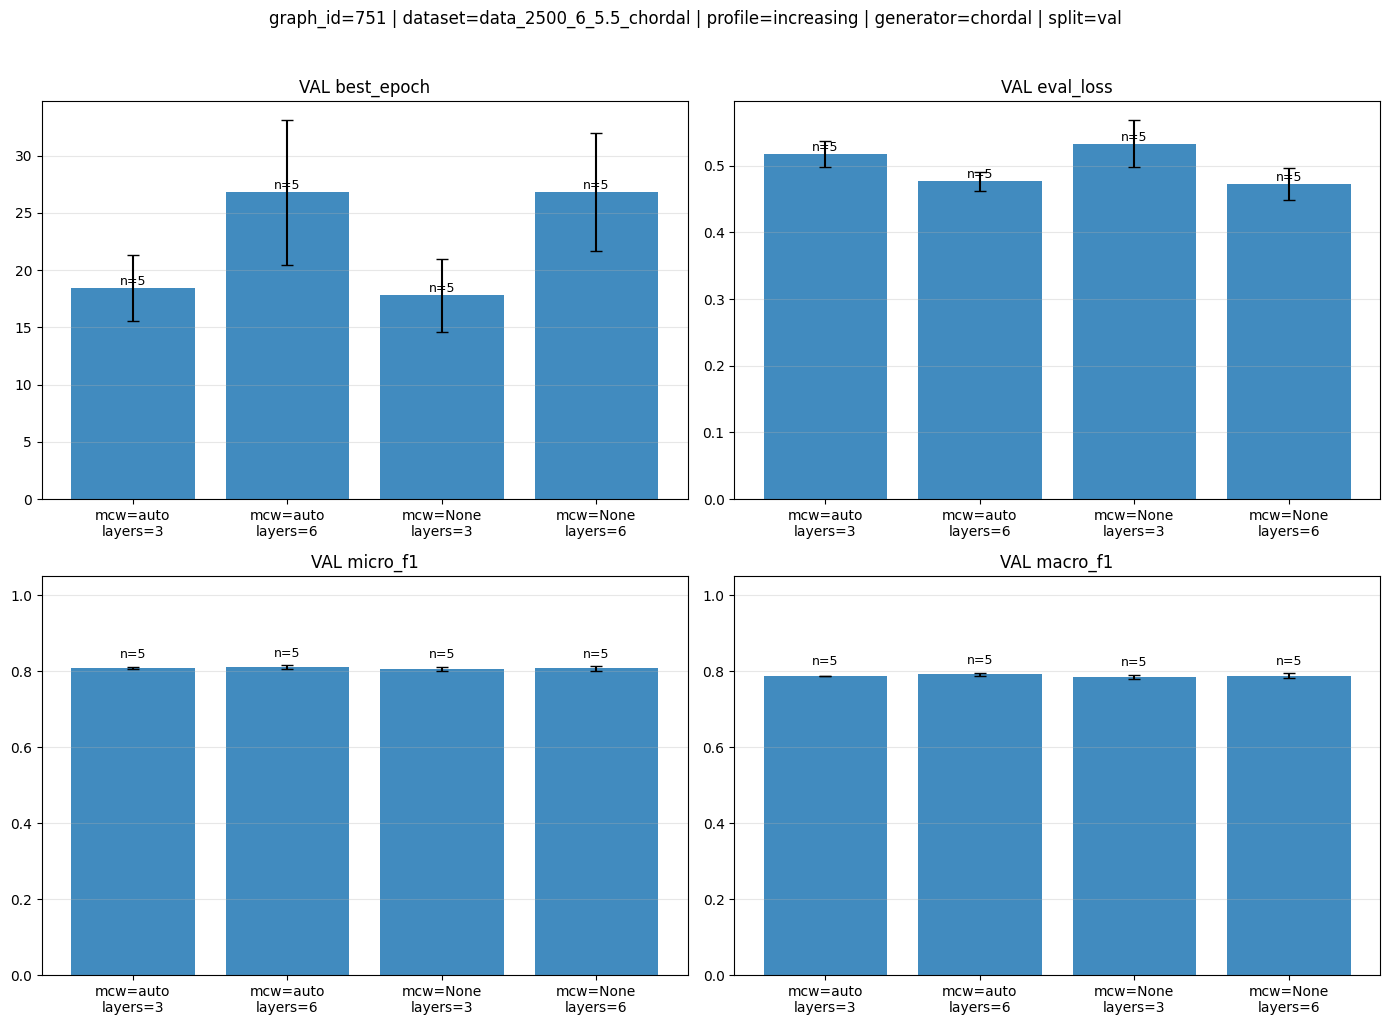

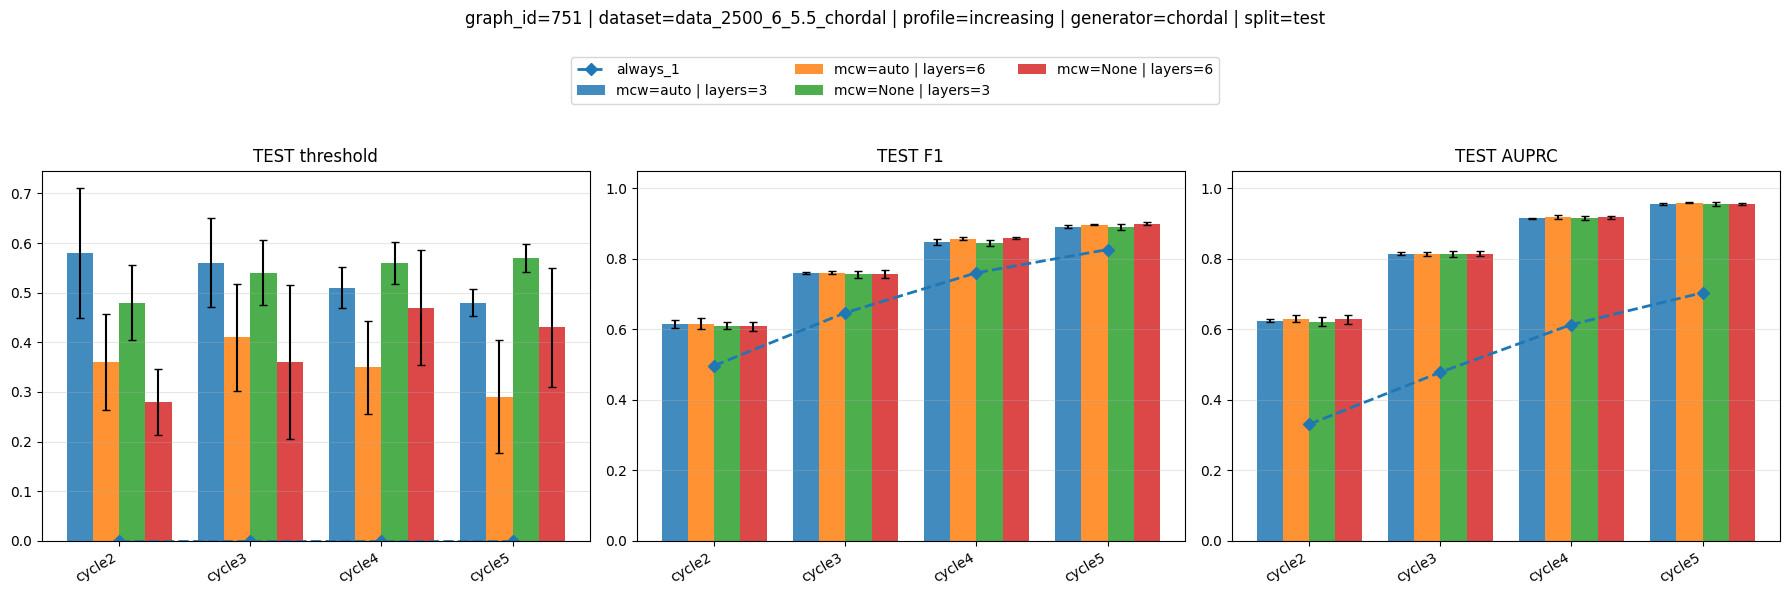

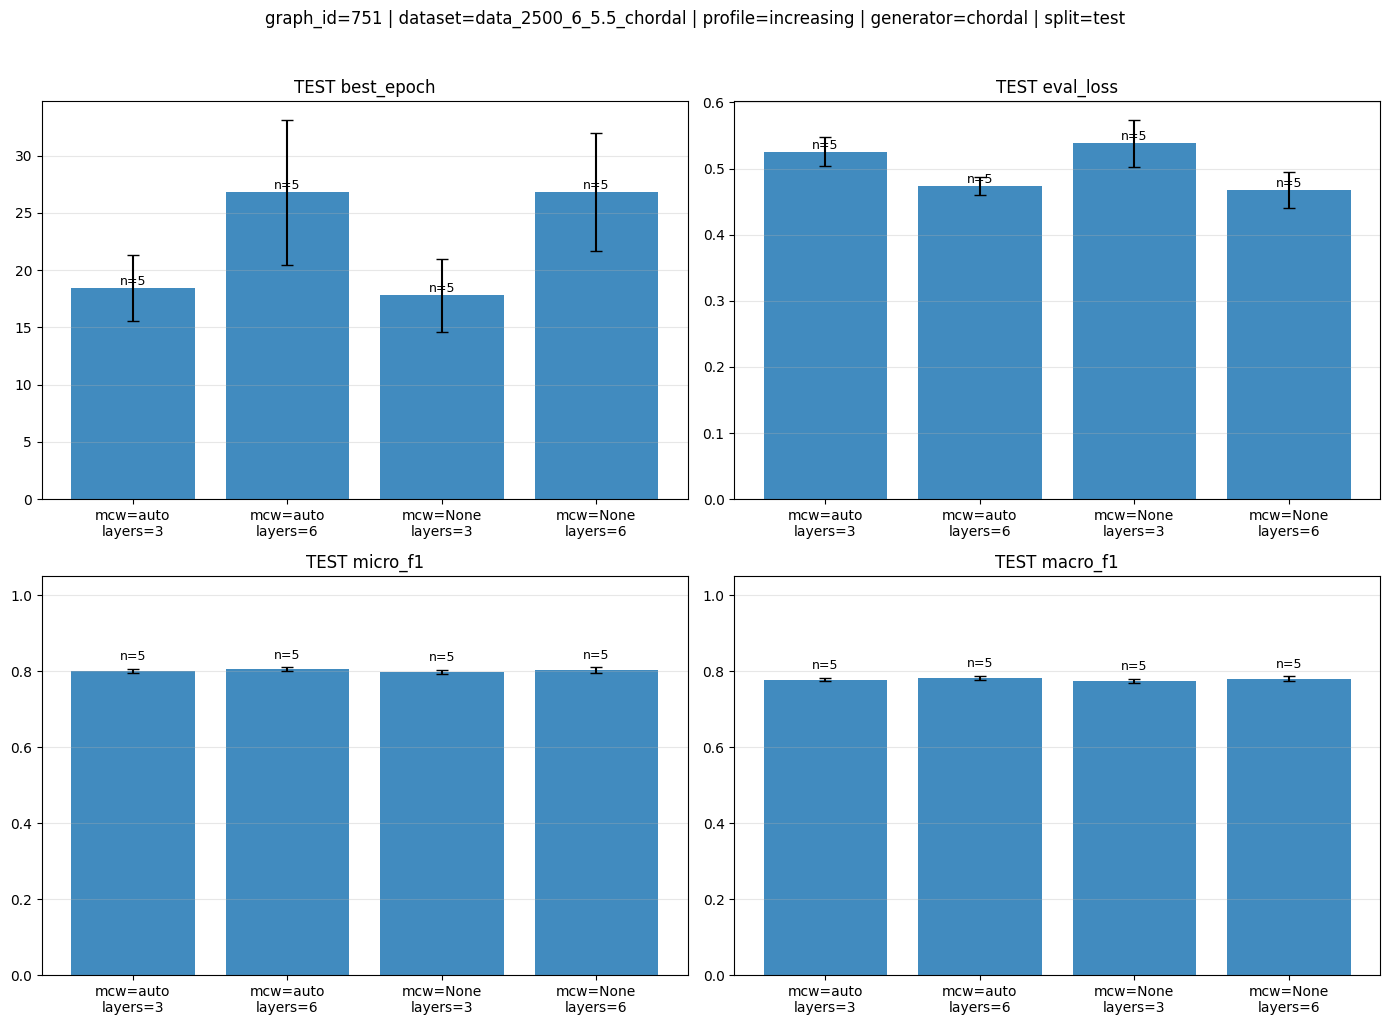


graph_id:  108
dataset_id:  data_2000_6_2.5_chordal
type:  chordal
selected_profile:  flat


,task,pos_rate_mean,pos_rate_max_diff_from_mean,pos_nodes_mean,pos_nodes_max_diff_from_mean
0,cycle2,0.541,0.007,1082.667,14.333
1,cycle3,0.623,0.024,1245.333,48.667
2,cycle4,0.660,0.009,1321.000,19.000
3,cycle5,0.662,0.013,1323.333,25.333


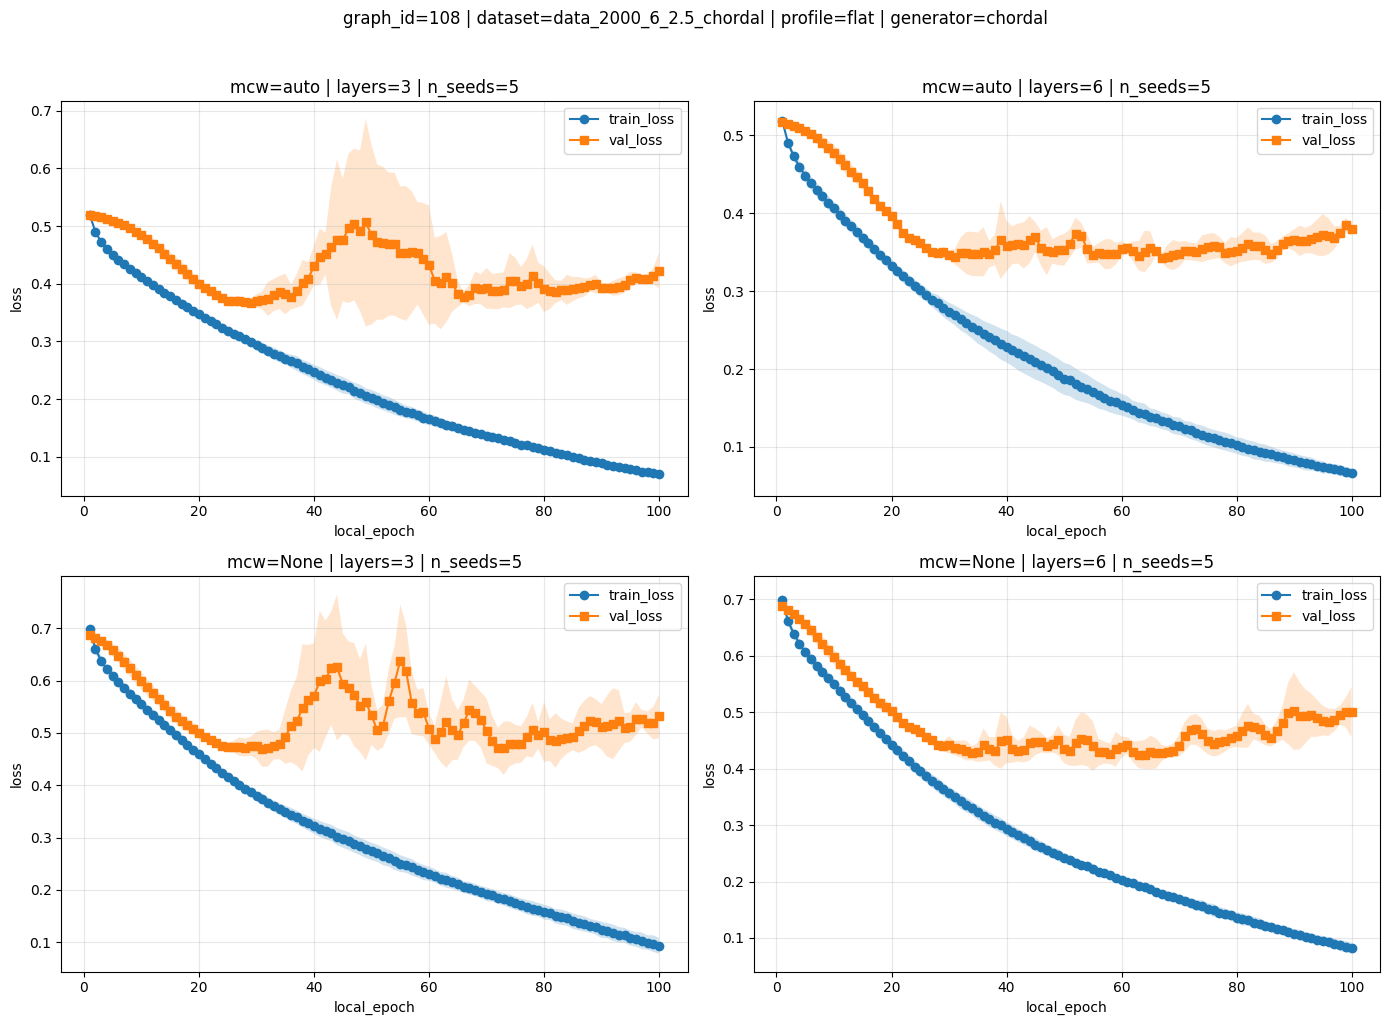

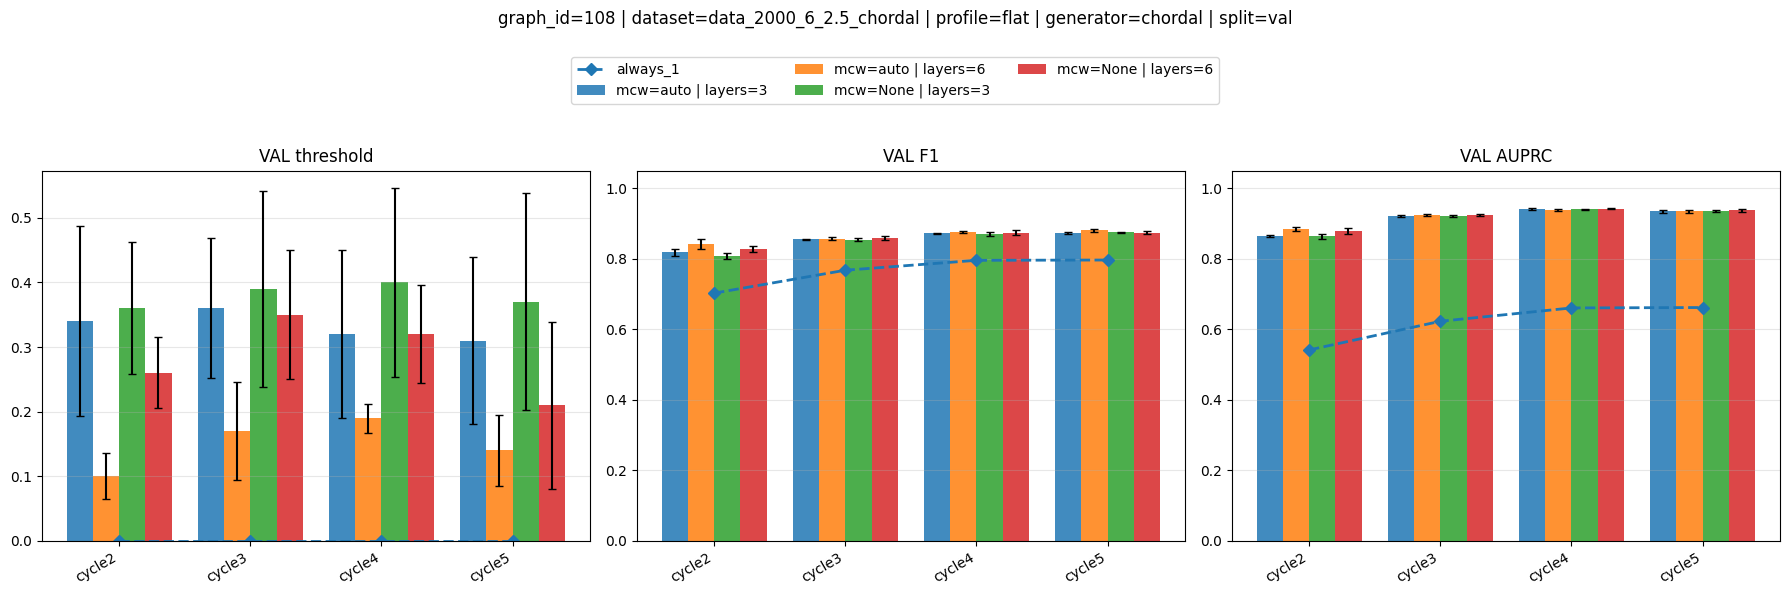

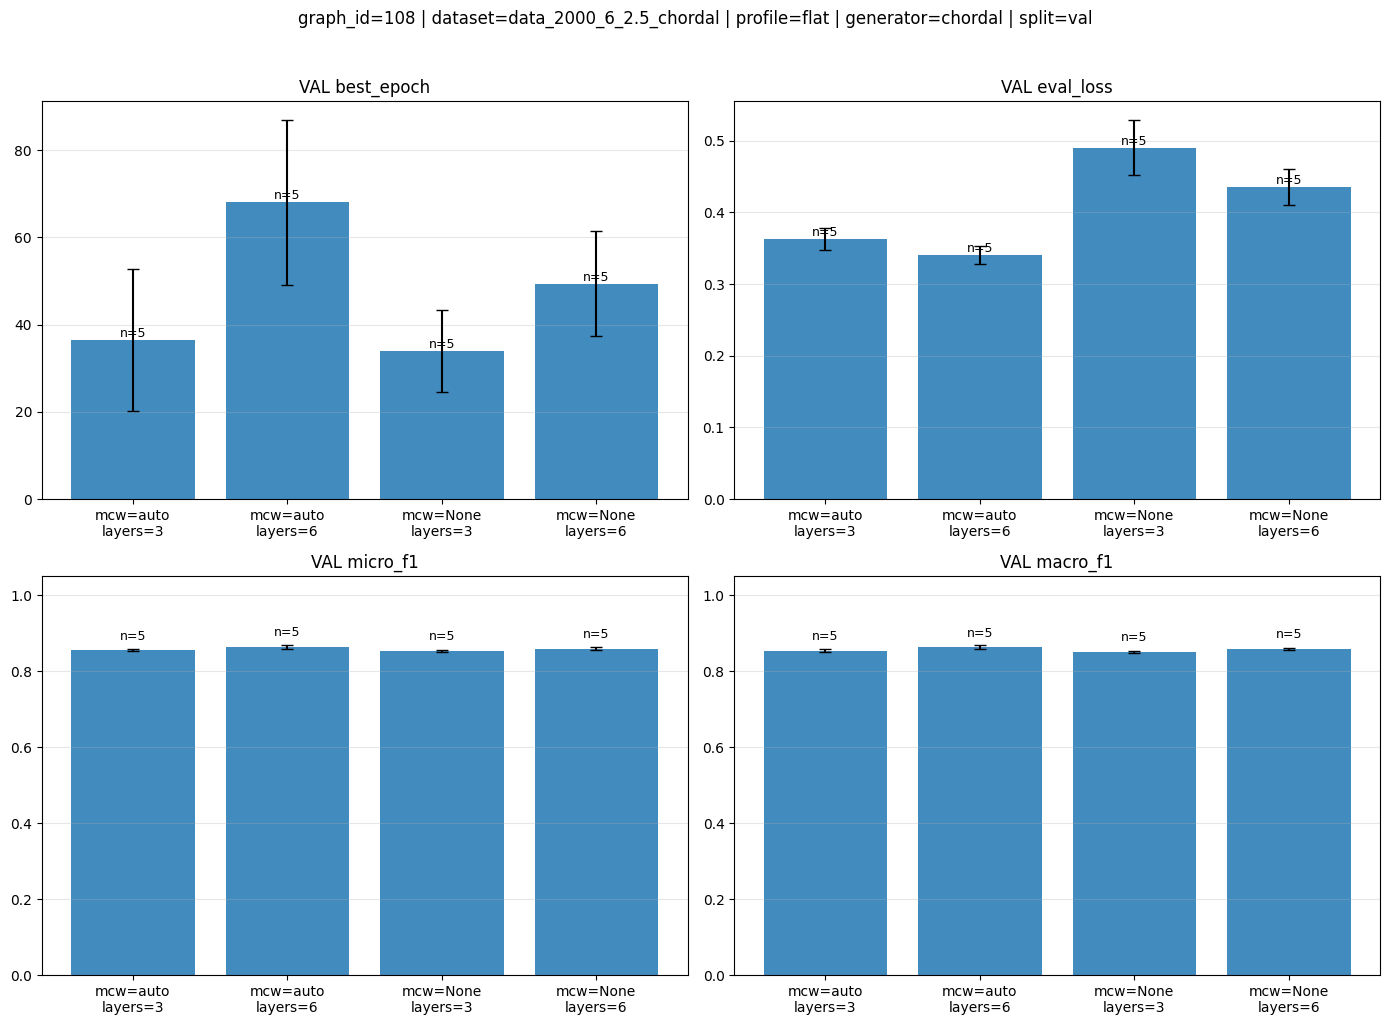

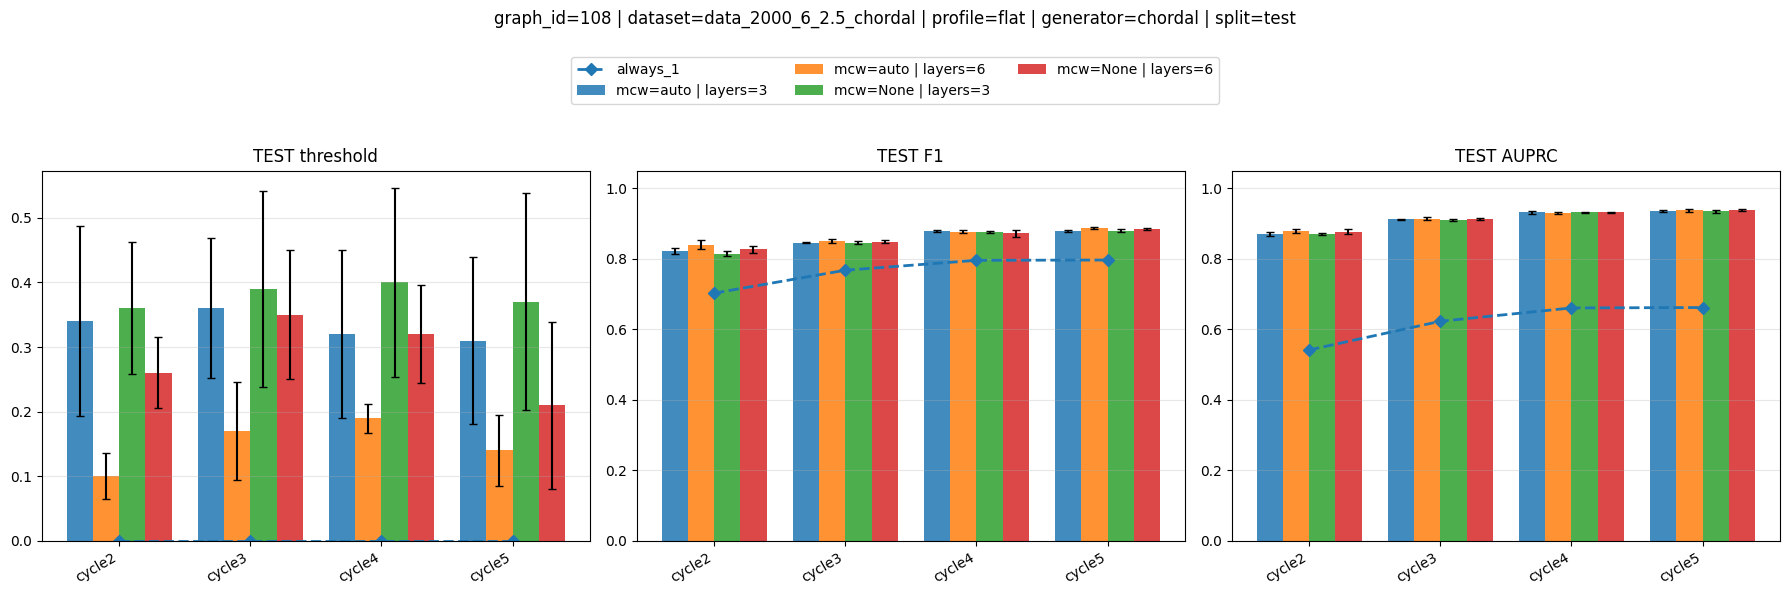

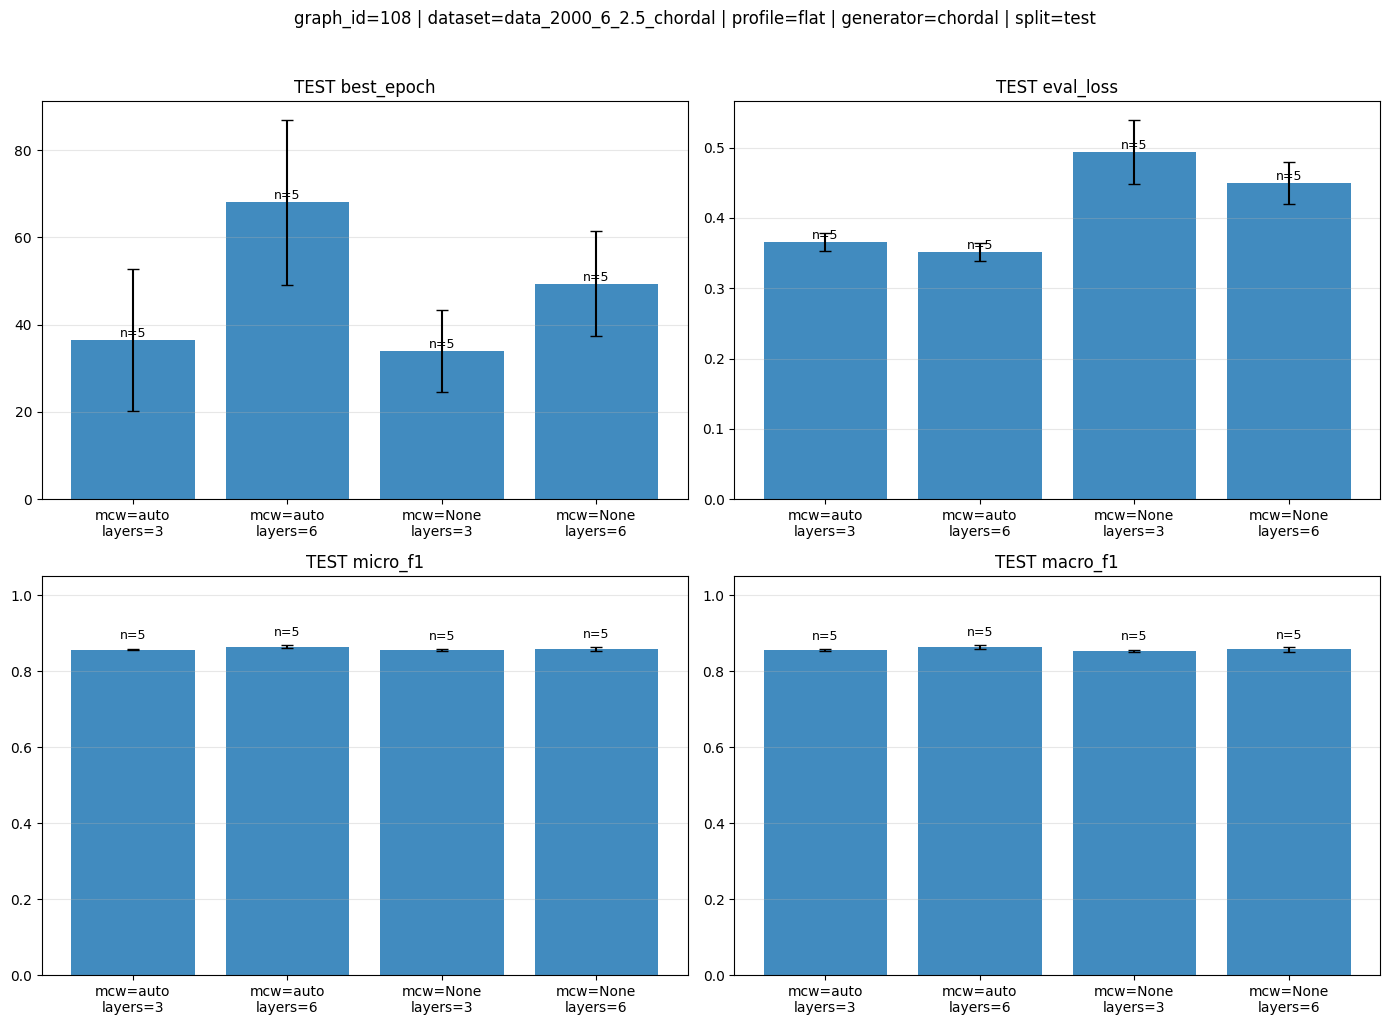


graph_id:  623
dataset_id:  data_1500_5_1.5_chordal
type:  chordal
selected_profile:  decreasing


,task,pos_rate_mean,pos_rate_max_diff_from_mean,pos_nodes_mean,pos_nodes_max_diff_from_mean
0,cycle2,0.575,0.017,862.000,25.000
1,cycle3,0.512,0.010,768.333,15.333
2,cycle4,0.390,0.016,585.333,23.333
3,cycle5,0.243,0.026,364.000,39.000


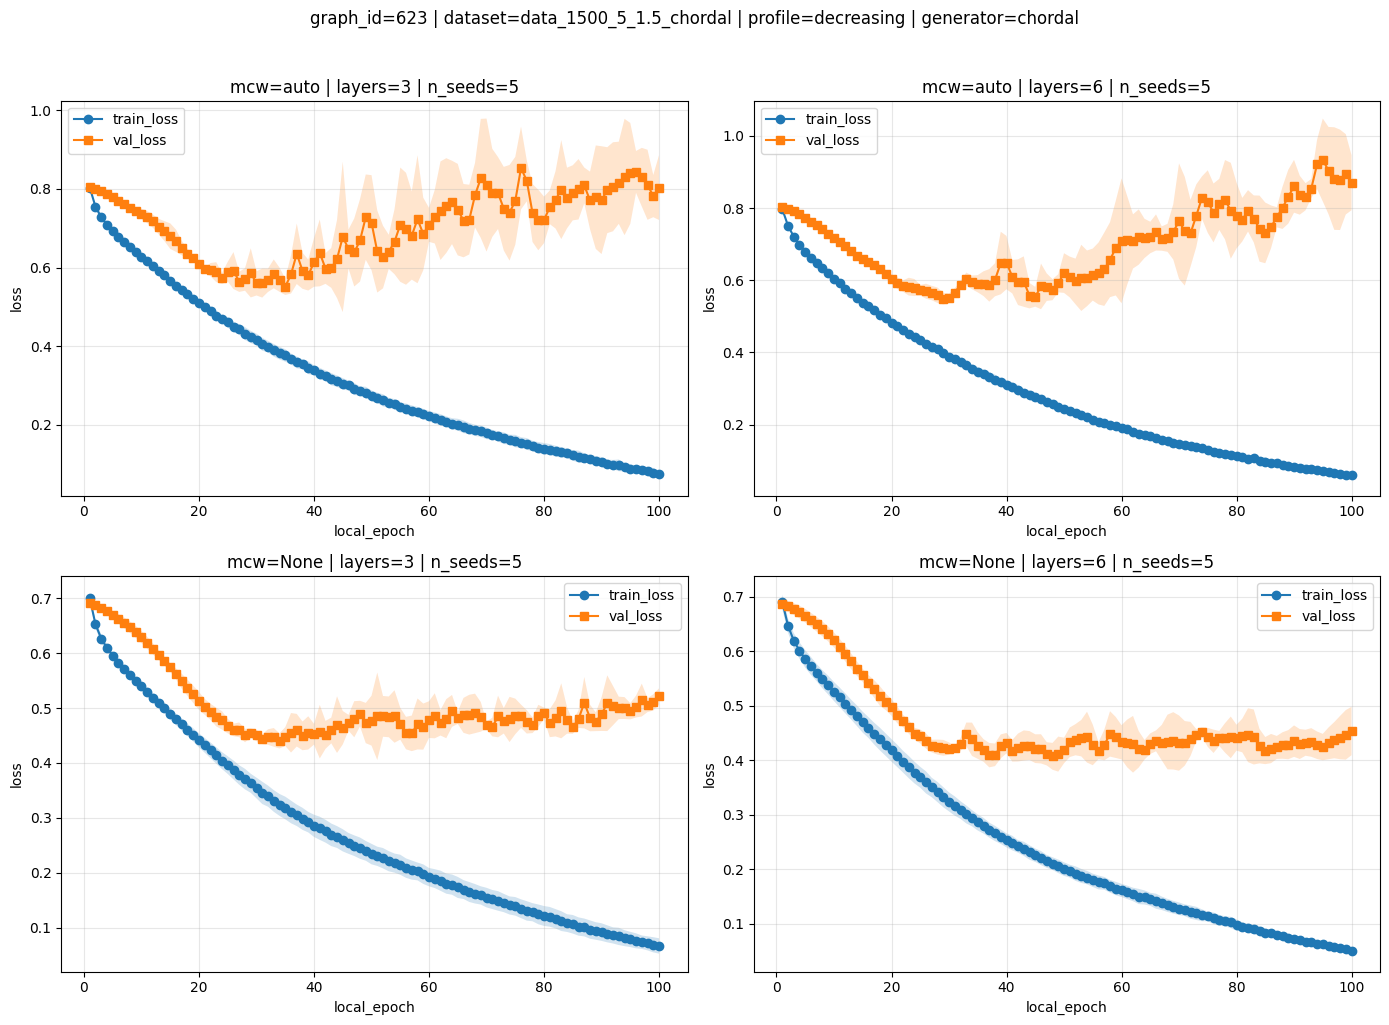

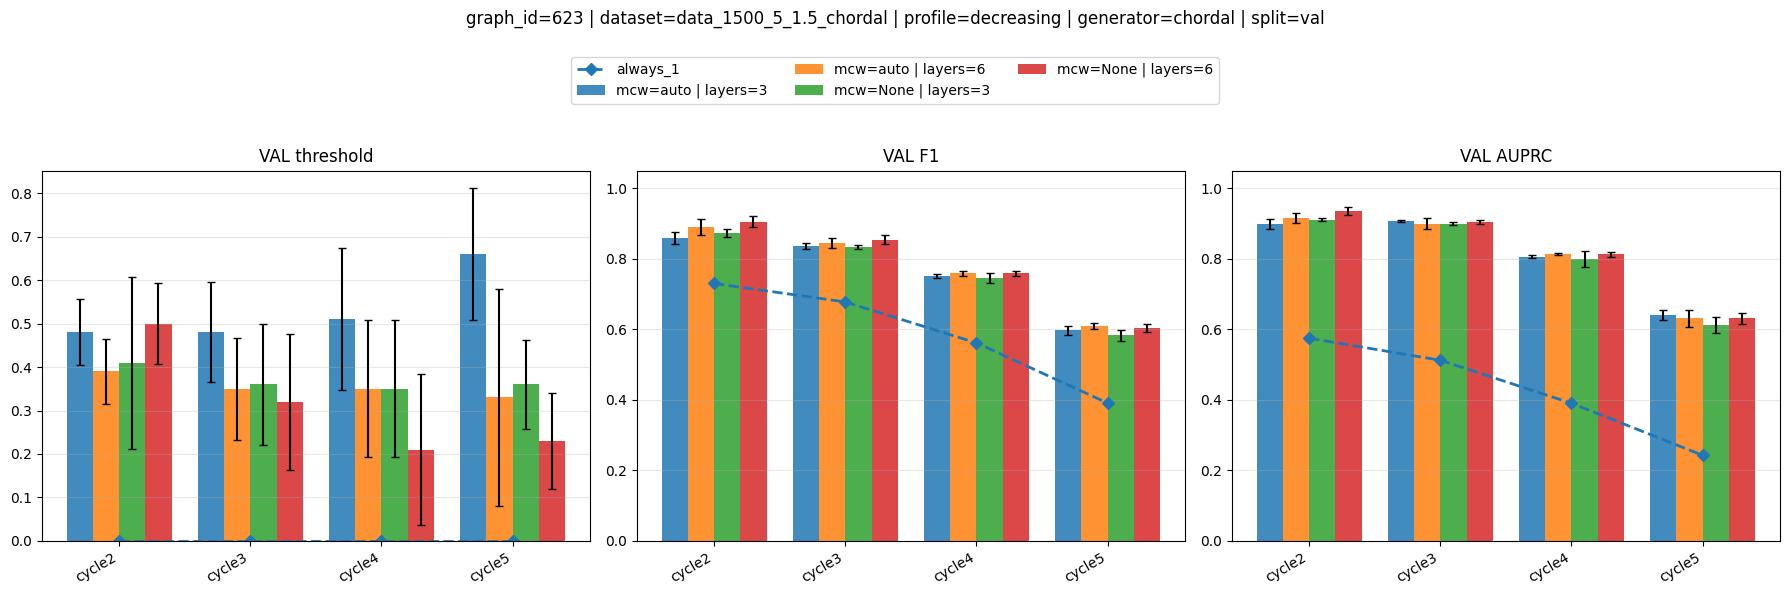

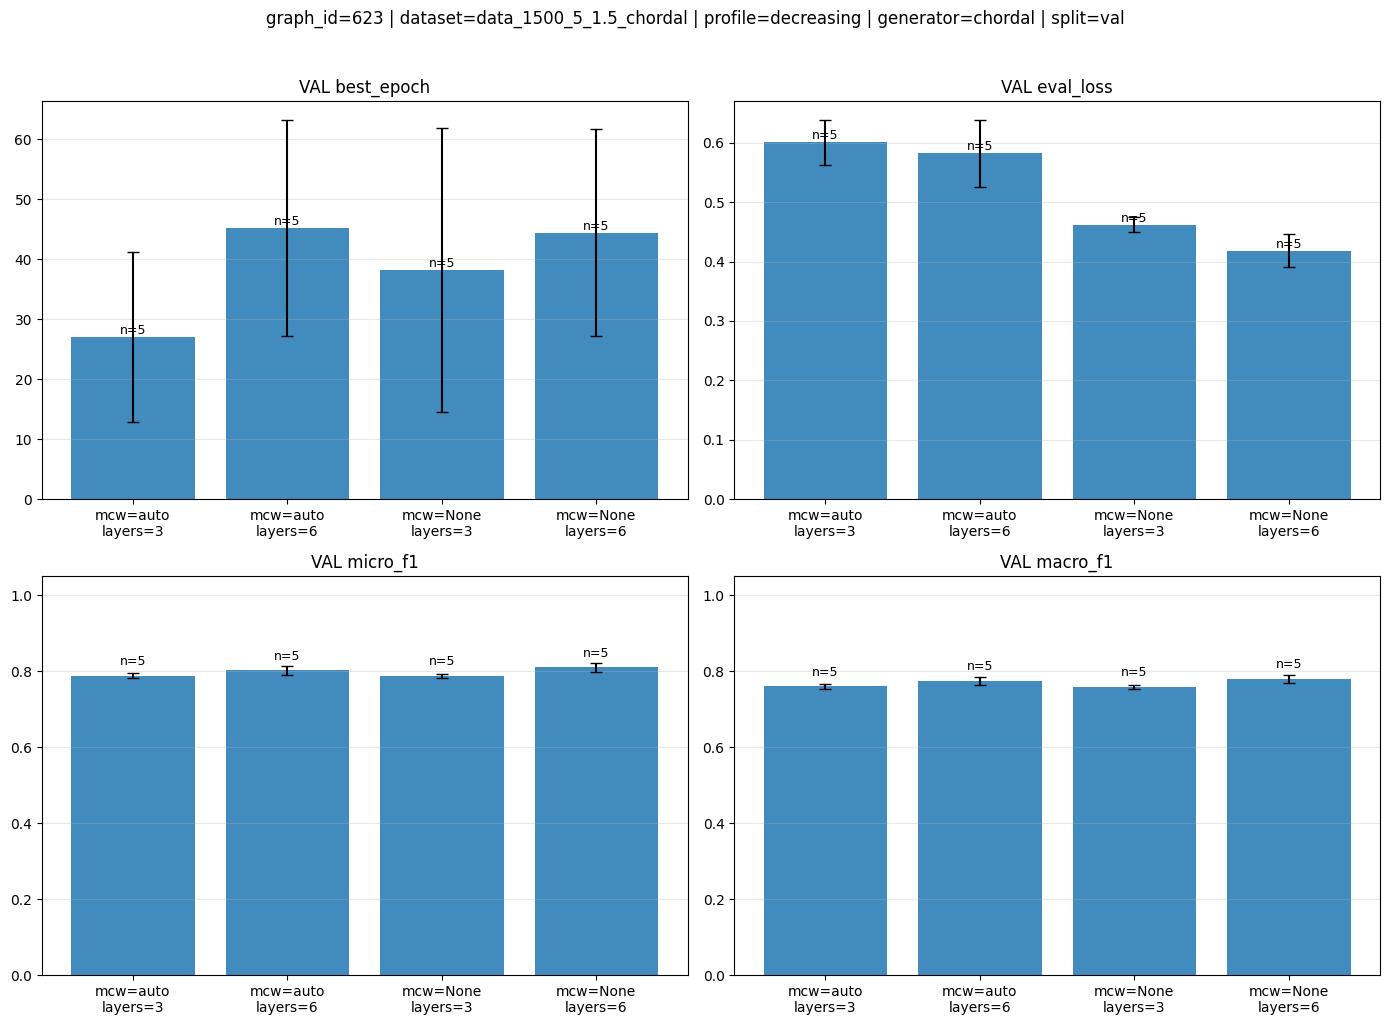

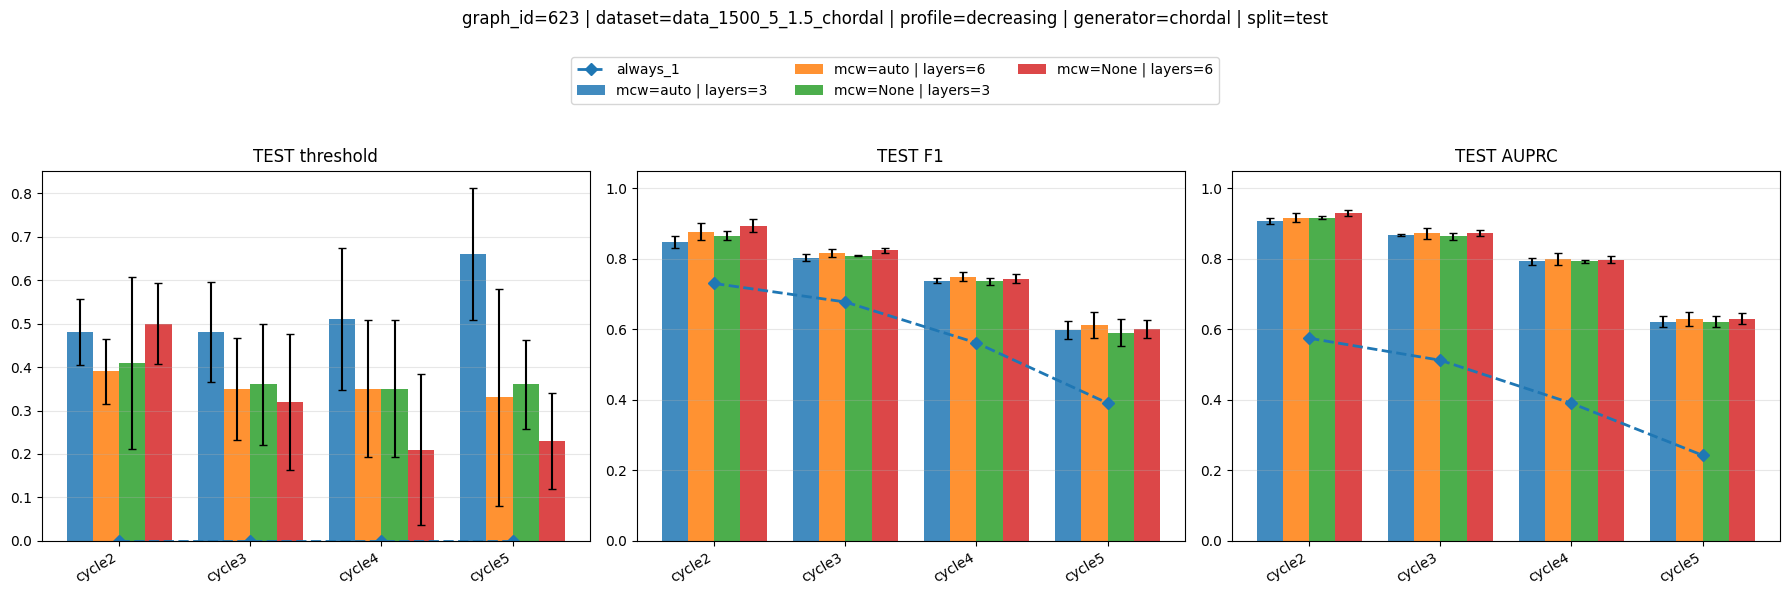

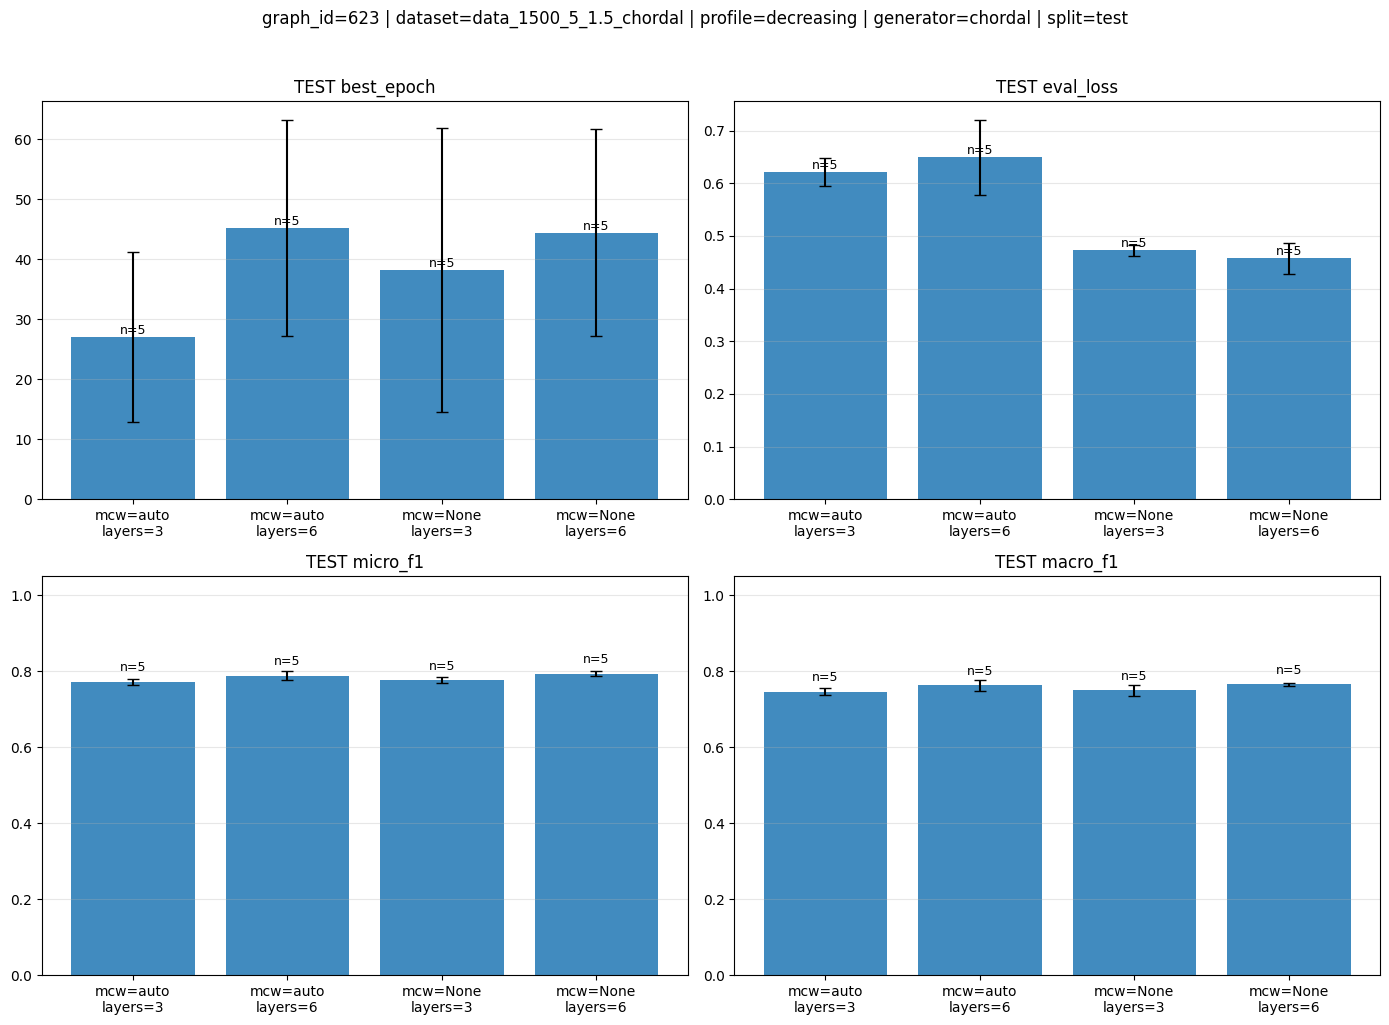


Saved loss plots:
- /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/plots_experiment_test_local/graph_751_losses_2x2.png
- /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/plots_experiment_test_local/graph_108_losses_2x2.png
- /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/plots_experiment_test_local/graph_623_losses_2x2.png

Saved val task metric plots:
- /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/plots_experiment_test_local/graph_751_val_task_metrics.png
- /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/plots_experiment_test_local/graph_108_val_task_metrics.png
- /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/plots_experiment_test_local/graph_623_val_task_metrics.png

Saved val scalar metric plots:
- /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/plots_experiment_test_local/graph_751_val_scalar_metrics.png
- /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/plots_experiment_t

In [9]:
PLOTS_ROOT = Path.cwd() / 'plots_experiment_test_local'
PLOTS_ROOT.mkdir(parents=True, exist_ok=True)

saved_loss_plots = []
saved_val_task_plots = []
saved_val_scalar_plots = []
saved_test_task_plots = []
saved_test_scalar_plots = []

for _, selected in train_graphs.iterrows():
    graph_id = selected['graph_id']
    graph_runs = collect_graph_runs(graph_id)

    print('\n' + '=' * 110)
    show_selected_overview(selected, TASKS)

    if graph_runs['run_exists'].sum() == 0:
        print('No run directories were found from the out_dir paths for this graph.')
        continue

    loss_plot_path = make_loss_figure_for_graph(selected, graph_runs, PLOTS_ROOT)
    saved_loss_plots.append(loss_plot_path)

    for split_name, task_store, scalar_store in [
        ('val', saved_val_task_plots, saved_val_scalar_plots),
        ('test', saved_test_task_plots, saved_test_scalar_plots),
    ]:
        scalar_df, task_df = summarize_best_split(graph_runs, split_name)

        if not task_df.empty:
            task_plot_path = make_task_metric_figure_for_graph(selected, task_df, PLOTS_ROOT, split_name)
            task_store.append(task_plot_path)
        else:
            print(f'No best_{split_name}_task rows found for task metric plot.')

        if not scalar_df.empty:
            scalar_plot_path = make_scalar_metric_figure_for_graph(selected, scalar_df, PLOTS_ROOT, split_name)
            scalar_store.append(scalar_plot_path)
        else:
            print(f'No best_{split_name} rows found for scalar metric plot.')

print('\nSaved loss plots:')
for p in saved_loss_plots:
    print('-', p)

print('\nSaved val task metric plots:')
for p in saved_val_task_plots:
    print('-', p)

print('\nSaved val scalar metric plots:')
for p in saved_val_scalar_plots:
    print('-', p)

print('\nSaved test task metric plots:')
for p in saved_test_task_plots:
    print('-', p)

print('\nSaved test scalar metric plots:')
for p in saved_test_scalar_plots:
    print('-', p)
